In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import os
from scipy.optimize import curve_fit

import scienceplots
plt.style.use(['science', 'ieee'])
plt.rcParams['figure.dpi'] = 300
from PythonAnalysis import *


In [2]:
N_bootstrap = 10000
FTMethod = "DFT"
fontsize = 15
kappa = 20
FrameTension="IsotropicFrameTension"
InitialConfiguration = "FromFlat"
N_k = 10

In [3]:
col_labels = [r"$n \pm \sigma_n$",r"$\kappa$",r"$\epsilon$",r"$\kappa_{{{\parallel}}}$",r"$\kappa_{{{\perp}}}$",r"$(j_1,j_2)$"]
table_data = []

In [4]:
Simulation = "OnlyMembrane"
InitialConfiguration = "FromFlat"


VFF = "no"
EPS = "no"
i1 = [0,1,0]; i2 = [5,5,6]
AnalysisFile=f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
data = load_boxsize_fourier_file(AnalysisFile)
values = data[('q','<u u>')]
datasets = [('q', '<u u>')]
for i in range(len(datasets)):
    q = data[datasets[i]][:, 0]
    hqn = data[datasets[i]][:, 1:]
    mean = np.mean(hqn, axis=1)
    hqn_error = bootstrap_point_errors(hqn,N=N_bootstrap)
    for j in range(len(i1)):
        mean_fitvalue, error_fitvalue = bootstrap(data[datasets[i]][i1[j]:i2[j]],hqn_error=hqn_error[i1[j]:i2[j]], N=N_bootstrap)
        X = np.linspace(q[i1[j]], q[i2[j]])
        table_data.append([
            rf"${mean_fitvalue[1]:.2f} \pm {error_fitvalue[1]:.2f}$",
            rf"${kappa}$",
            rf"$0$",
            rf"$0$",
            rf"$0$",
            rf"{i1[j],i2[j]}"
        ])

In [5]:
# Simulation = "OnlyVectorField"
# InitialConfiguration = "FromFlat"

# VFF = "no"
# #i1 = [0,0,0]; i2 = [3,5,12]
# i1 = [0]; i2 = [5]
# EPS_list=[0]
# for EPS in EPS_list:
#     AnalysisFile=f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
#     data = load_boxsize_fourier_file(AnalysisFile)
#     values = data[('q','<u u>')]
#     datasets = [('q', '<u u>')]
#     for i in range(len(datasets)):
#         q = data[datasets[i]][:, 0]
#         hqn = data[datasets[i]][:, 1:]
#         mean = np.mean(hqn, axis=1)
#         hqn_error = bootstrap_point_errors(hqn,N=N_bootstrap)
#         for j in range(len(i1)):
#             mean_fitvalue, error_fitvalue = bootstrap(data[datasets[i]][i1[j]:i2[j]],hqn_error=hqn_error[i1[j]:i2[j]], N=N_bootstrap)
#             X = np.linspace(q[i1[j]], q[i2[j]])
#             table_data.append([
#                 rf"${mean_fitvalue[1]:.2f} \pm {error_fitvalue[1]:.2f}$",
#                 rf"${kappa}$",
#                 rf"${EPS}$",
#                 rf"$0$",
#                 rf"$0$",
#                 rf"{i1[j],i2[j]}"
#             ])

In [6]:
Simulation = "VFMCoupling"
InitialConfiguration = "FromFlat"

VFF = "no"
#i1 = [0,0,0]; i2 = [3,5,12]
i1 = [0,1,0]; i2 = [5,5,6]
EPS_list=[1,2,5]
KP_list =[1,10]
for KP in KP_list:
    for EPS in EPS_list:
        KL = KP / 2
        KL = round(KL, 10)          # avoid float noise like 0.30000000000000004
        KL_str = f"{KL:g}"          # strips trailing zeros: "0.5" instead of "0.500000"
        AnalysisFile=f"{FrameTension}/{InitialConfiguration}/{Simulation}/VFF{VFF}/EPS{EPS}/KP{KP}KL{KL_str}/StaticUndulationSpectrum/{FTMethod}{N_k}.txt"
        data = load_boxsize_fourier_file(AnalysisFile)
        values = data[('q','<u u>')]
        datasets = [('q', '<u u>')]
        for i in range(len(datasets)):
            q = data[datasets[i]][:, 0]
            hqn = data[datasets[i]][:, 1:]
            mean = np.mean(hqn, axis=1)
            hqn_error = bootstrap_point_errors(hqn,N=N_bootstrap)
            for j in range(len(i1)):
                mean_fitvalue, error_fitvalue = bootstrap(data[datasets[i]][i1[j]:i2[j]],hqn_error=hqn_error[i1[j]:i2[j]], N=N_bootstrap)
                X = np.linspace(q[i1[j]], q[i2[j]])
                table_data.append([
                    rf"${mean_fitvalue[1]:.2f} \pm {error_fitvalue[1]:.2f}$",
                    rf"${kappa}$",
                    rf"${EPS}$",
                    rf"${KP}$",
                    rf"${KL_str}$",
                    rf"{i1[j],i2[j]}"
                ])

In [7]:
print(f"col_labels length: {len(col_labels)}")
for i, row in enumerate(table_data):
    if len(row) != len(col_labels):
        print(f"Row {i} has {len(row)} columns: {row}")

col_labels length: 6


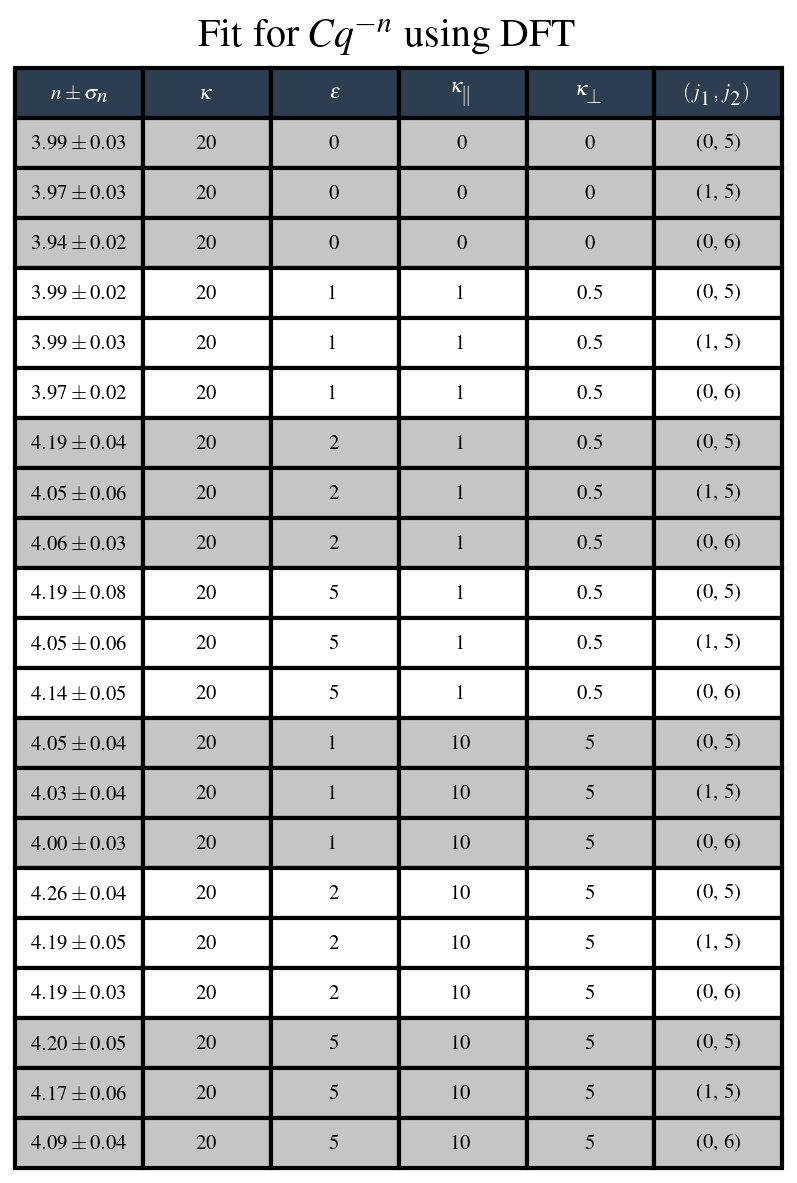

In [9]:
fig, ax = plt.subplots()
ax.axis("off")

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)

for col_idx in range(len(col_labels)):
    table[0, col_idx].set_facecolor("#2c3e50")
    table[0, col_idx].set_text_props(color="white", fontweight="bold")

for row_idx in range(1, len(table_data) + 1):
    block = (row_idx - 1) // 3
    color = "#c6c5c5" if block % 2 == 0 else "white"
    for col_idx in range(len(col_labels)):
        table[row_idx, col_idx].set_facecolor(color)

fig.suptitle(rf"Fit for $Cq^{{-n}}$ using {FTMethod}", y=1.3)  # tune y until it sits right above the table

#outdir = f"Plots/IsotropicFrameTension/{InitialConfiguration}/OnlyVectorField"
outdir = f"Plots/IsotropicFrameTension/{InitialConfiguration}/VFMCoupling"
#outdir += f"KP{KP}KL{KL}" if (KP != "no" or KL != "no") else ""
os.makedirs(outdir, exist_ok=True)
#fig.savefig(f"{outdir}/UndulationTable_WithAll.pdf", bbox_inches="tight")
fig.savefig(f"{outdir}/UndulationTable{FTMethod}.pdf", bbox_inches="tight")
plt.show()